### ```End-To-End Data Analytics Project: Titanic Data Analysis```

**Project Workflow:**
```py
        Business Problem
            |
        Dataset Understanding
            |
        Data Quality Assessment
            |
        Data Cleaning & Preparation
            |
        Exploratory Data Analysis (EDA)
            |
        Visualization
            |
        Insights / Findings
            |
        Recommendations
            |
        Conclusions
```

##### ```1. Business Problem:```

"Analyze Titanic Passengers data to identify factors affecting survival".

- What factors influenced passengers to survive.
- Ask Question Why, How, what, which


**Analytics:**
- Identify Survival patterns
- Understand high-risk passenger groups.
- Find relationships between demographics and survival.
- Generate insights using historical passenger data.

In [1]:
#Importing necessary libraries for analysis.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### ```2. Dataset Understanding```
- Reading the data from the source.
- Head() to validate the data in dataframe format by looking at the data.


Checks:
- Understand the data
- Columns check (dependent/Independent columns)
- How many records (rows & Columns)
- Describe & Info to understand statistically manner.
- Finding Target variable (How it is dependent with other columns)

In [2]:
# Reading the CSV File.
df = pd.read_csv('Titanic.csv')  #We have the csv in project folder so we can directly use the name or else we need to give whole path.

In [3]:
#Displaying the CSV data using Head() for 5 rows to validate in DataFrame format.
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Checking what columns are present
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

**Columns:**
- PassengerID: Unique Passenger Number
- Survived: 0-Not Survived, 1-Survived
- Pclass: Passenger Class
- Name: Name of the passenger
- Sex: Male, Female
- Age: Passenger Age at the time of travel
- Sib Sp: Sibilings / Spouse present on Titanic
- Parch: Parents / Children present on Titanic
- Ticket: Unique passenger Ticket
- Fare: Price for the travel
- Cabin: Compartment class of booking.
- Embarked: Boarding Point

In [5]:
#Shape of the data
df.shape

(891, 12)

#### ```3. Data Quality Assessment```

- Missing Values Checks
- Duplicates
- Wrong Data types
- Invalid values
- Outliers

In [6]:
#Checking the Information.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Observations:**
```py
- We can see that a total of 891 rows and 12 Columns exist in the dataset
- 11 feature inputs and 1 Target Variable (Survived)
- Each column has its own datatypes.
- We can see the Age, Cabin column has more missing values than Embarked column.
- Ticket & Name Columns are potentially lower priority.
```


**Proceedings:**
```py
- If there are any mismatch in the column datatypes we can typecast to desired datatypes.
- From the missing rows, we can validate them and proceed with either Imputation or dropping the rows based on null percentage.
- We can cross check the Cabin column and based on that we can decide whether we need to drop or untouch.

Generally if a column has 60% Null values we can proceed with Imputation of Mean, median, or mode based on columns, and if columns are 20% we can proceed with dropping them.

- We need to check the Age distribution and based on that we need to decide
- Is the distribution is normal or skewed?

Note: Age will not be normal as they are passenger of different groups like children, adults, elders. If distribution is Skewed use "Median".
```


In [7]:
#Statistical Summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
#Checking for Null values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [10]:
#Finding the duplicate rows
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [11]:
#Suppose your data is having duplicates then use below code:
#df = df.drop_duplicates()

**Observation:**
```py
- Age: Need to check distribution based on that if normal we can go for Mean or else skewed we can go with Median.
- Cabin: Need to understand the column more if it gives any feature benefits which are having values based on that we can take further.
- Embarked: There are only two so we can drop or else we can go with mode.

=> We can observe from unique values of the feature columns
- Survived: 0 and 1 [Target Variable/Dependent Variable]
- Pclass: First Class, Second Class, third Class
- Sex: Male and Female
- Embarked: S, C, & Q

=> We can observe that there are no duplicate rows present in the data, we could have identified before cell of unique values as they are 891 rows and we got 891 unique rows.

```

#### ```4. Data Cleaning & Preparation```

- Handling Missing Values
- Removing Duplicates
- Type Casting columns
- Feature Engineering

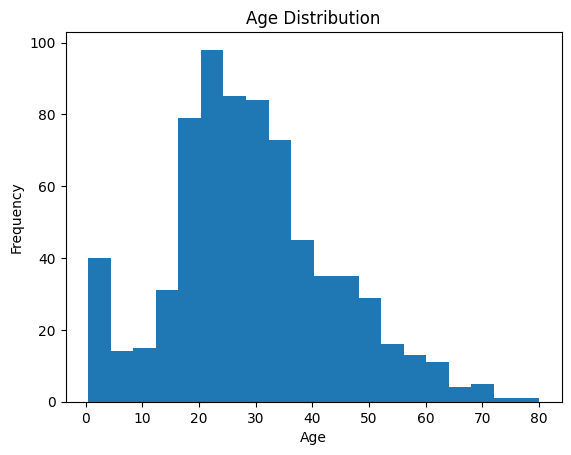

In [12]:
#Check Age Distribution to impute accordingly

plt.hist(df['Age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title("Age Distribution")
plt.show()

In [13]:
#Statistical Summary
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

**Observation:**
- We can observe that the distribution is right skewed.
- High concentration of Young Adults effected, Most of the people were Young Adults on Titanic.

Right Skewed:
- mean(29.6) > median(28) --> This is due to the distribution of elderly people is being pulled from outlier tail, while the median stay resistant with the distribution.

**Age Breakdown:**
- 40-60 people were children age between 0 to <15.
- More than 400+ people from young adults aged between 15 to 60.
- Middle Aged and elderly have a slighlty declined in the graph.


<> From the above obeservation we can find the data is 'Skewed'. Hence, we need to use the 'Median' imputation strategy.

In [14]:
#Imputation of Age with Median
df['Age'] = df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\raksh\AppData\Local\Temp\ipykernel_16700\234198238.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'] = df['Age'].fillna(df['Age'].median(), inplace=True)


In [15]:
#Impute Embarked column with mode as they are only two null values, we use strategy of mode on this categorical data.
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

C:\Users\raksh\AppData\Local\Temp\ipykernel_16700\2701906339.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [16]:
#We are pulling the Cabin column which represents the deck series like example 'C65' = C as the number could be any in the respective cabin deck.

df['Deck'] = df['Cabin'].str[0]

- As we pulled the Cabin deck information, we need to fill the null values with Unknown as we can directly judge the cabin with median or mode as those information is not support with other row data.

- This will help in handling high cardinality into a usefull categorical variables.

In [17]:
#Creating a new column and filling the null values with 'Unknown' as those are non continuous values.
df['Deck'] = df['Deck'].fillna("Unknown")

In [18]:
#We have extracted the known values into 0 & 1 so that we can investigate how this relate with other columns
df['Cabin_known'] = df['Cabin'].notna().astype('int')

In [19]:
#We are check the both values
df['Cabin_known'].value_counts()

Cabin_known
0    687
1    204
Name: count, dtype: int64

- Cabin exist --> 1
- Cabin missing --> 0

```Data Type check on columns```
- Survived --> Integer
- Pclass --> integer
- Age --> Numeric
- Fare --> Numeric
- Sex --> Categorical
- Embarked --> Categorical

#### ```5. Feature Engineering```

In [20]:
#We are creating a family column to check if the passenger is part of any family group or travelling alone.
df['Family_size'] = df['SibSp'] + df['Parch'] + 1

In [21]:
#We are pulling the passenger travelling alone feature.
df['Is_alone'] = (df['Family_size'] == 1).astype('int')

# Family size = 1 --> is alone = 1
# Family size > 1 --> is alone = 0

#### ```6. Exploratory Data Analysis [EDA]```

**Q1. What was the Survival rate?**

In [22]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [23]:
df['Survived'].value_counts(normalize=True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

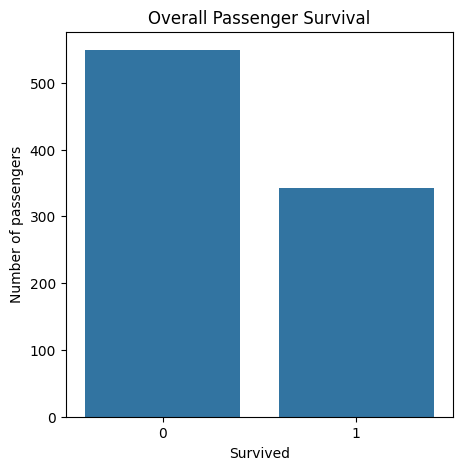

In [24]:
plt.figure(figsize=(5,5))
sns.countplot(data=df, x='Survived')
plt.title("Overall Passenger Survival")
plt.xlabel("Survived")
plt.ylabel("Number of passengers")
plt.show()

**Observations:**
- Approxmately 38% were able to survive, while 63% were not survived.

**Q2 - Does Gender appear associated with Survival?**

In [25]:
pd.crosstab(
    df['Sex'],
    df['Survived'],
    normalize=True
)*100

Survived,0,1
Sex,,
female,9.090909,26.150393
male,52.525253,12.233446


In [26]:
df.groupby(df['Sex'])['Survived'].mean() * 100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

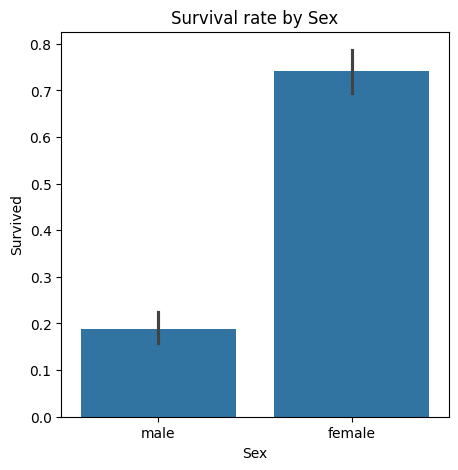

In [27]:
plt.figure(figsize=(5,5))
sns.barplot(data=df,x='Sex', y='Survived')
plt.title("Survival rate by Sex")
plt.show()

**Observation:**
- We can observe that Sex had associated with the survival rate as first factor of analysis. This parameter need to check with other categories to check how the most female rate has survived and what are the parameter like Age Group, Pclass, and so on.

**Q3.  Does Passenger class matter?**

In [28]:
df.groupby('Pclass')['Survived'].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

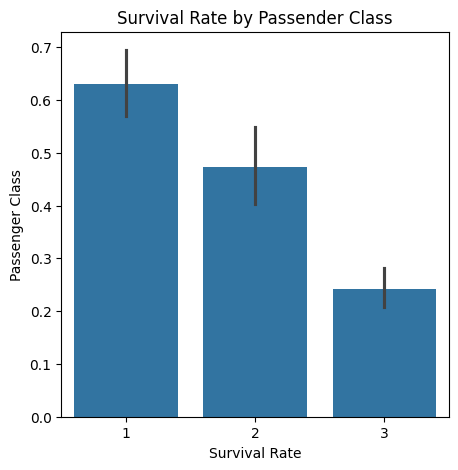

In [29]:
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='Pclass',y='Survived')
plt.title("Survival Rate by Passender Class")
plt.xlabel("Survival Rate")
plt.ylabel("Passenger Class")
plt.show()

In [30]:
pd.crosstab(
    [df['Pclass'], df['Sex']],
    df['Survived'],normalize="index"
)* 100

Survived               0          1
Pclass Sex                         
1      female   3.191489  96.808511
       male    63.114754  36.885246
2      female   7.894737  92.105263
       male    84.259259  15.740741
3      female  50.000000  50.000000
       male    86.455331  13.544669

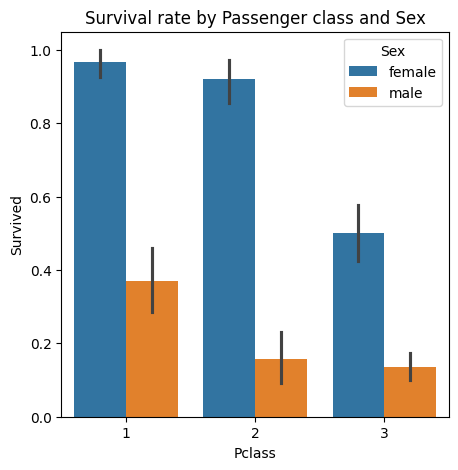

In [31]:
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex')
plt.title("Survival rate by Passenger class and Sex")
plt.show()

**Observation:**
- We can observe that 62% of the survival were P1 class and most of them were Females with 96% and 36% were males in the group.
- P1 > P2 > P3 in all the groups females has higher survival rate.
- **Header point:** We can conclude that Passenger class has played a crucial role in survial.

**Q4. Does Age matter?**

In [32]:
df.groupby('Survived')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,30.028233,12.499986,1.00,23.0,28.0,35.0,74.0
1,342.0,28.291433,13.764425,0.42,21.0,28.0,35.0,80.0


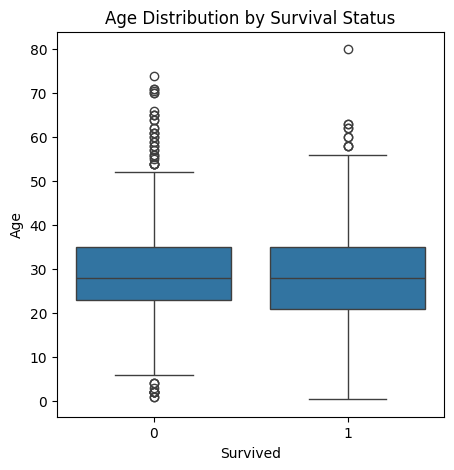

In [33]:
plt.figure(figsize=(5,5))
sns.boxplot(
    data=df,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival Status")
plt.show()

**Q5. Age Group interpretation**

In [34]:
bins = [0,12,18, 30, 45, 60, 100]

labels = [
    'Child',
    'Teenager',
    'Young Adult',
    'Adult',
    'Middle Aged',
    'Senior'
]

df['age_group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [35]:
df.groupby('age_group',observed=True)['Survived'].mean() * 100

age_group
Child          57.971014
Teenager       42.857143
Young Adult    33.109620
Adult          42.574257
Middle Aged    40.740741
Senior         22.727273
Name: Survived, dtype: float64

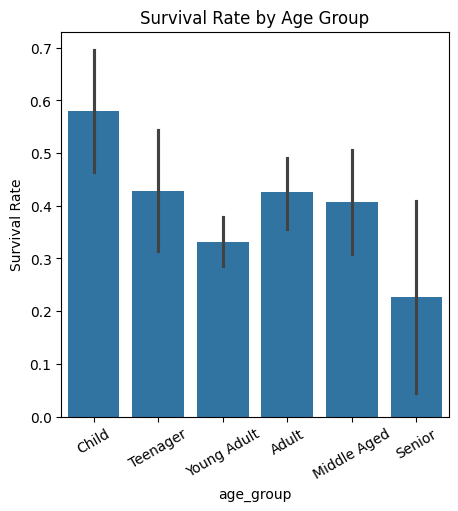

In [36]:
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='age_group', y='Survived')
plt.xticks(rotation=30)
plt.ylabel('Survival Rate')
plt.title("Survival Rate by Age Group")
plt.show()

**Observation:**
- We can interpret that Child has 57% of survival compared to Senior with 22%.

**Q6. Does Family has all survival?**

In [38]:
df.groupby('Family_size')['Survived'].mean() * 100

Family_size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

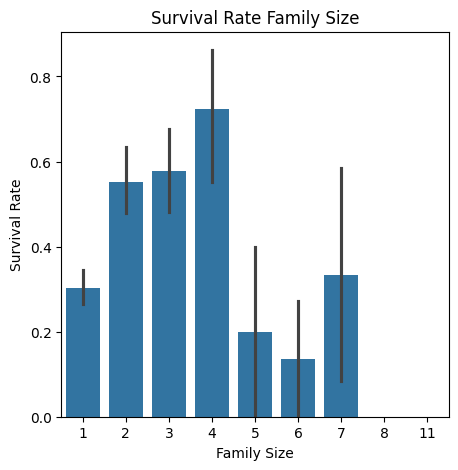

In [39]:
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='Family_size', y='Survived')
plt.title("Survival Rate Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

**Observations:**
- There is unusal pattern in the groups.
- People with group size above 8 have unstable chances of survival.
- We might have a question why is the family size of 4 has huge survival rate what might be the possibilities of their survival is it they were most in best passenger class?

In [51]:
df[df["Family_size"] == 4].groupby('Pclass')['Survived'].mean()

Pclass
1    0.714286
2    0.769231
3    0.666667
Name: Survived, dtype: float64

- We can see that the family size = 4 were present in Pclass = 1,2 has more survival. Passenger class played a role in survival.

**Q7. Travelling alone vs Group**

In [52]:
df.groupby('Is_alone')['Survived'].mean() * 100

Is_alone
0    50.564972
1    30.353818
Name: Survived, dtype: float64

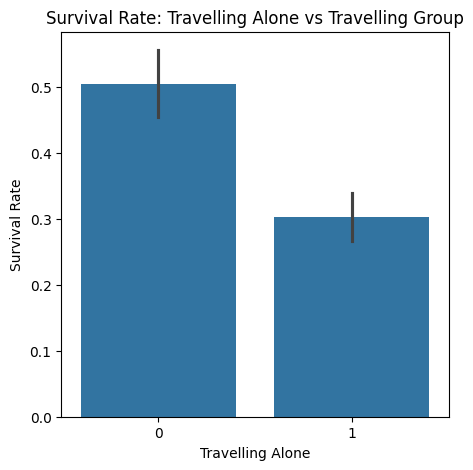

In [53]:
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='Is_alone', y='Survived')
plt.title("Survival Rate: Travelling Alone vs Travelling Group")
plt.xlabel("Travelling Alone")
plt.ylabel("Survival Rate")
plt.show()

**Observations:**
- 0--> With Family, 1--> Alone, can see that travelling alone has been less survival and group has better influence in survival.

**Q8. Is Fare associated with the survival?**

In [56]:
df.groupby('Survived')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,22.117887,31.388207,0.0,7.8542,10.5,26.0,263.0000
1,342.0,48.395408,66.596998,0.0,12.4750,26.0,57.0,512.3292


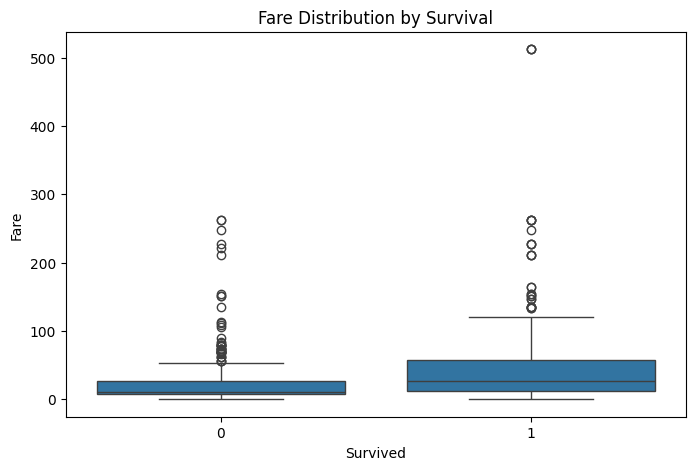

In [59]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare Distribution by Survival')
#plt.yscale('log')
plt.show()

**Observation:**
- We can see that substantial skew of the data recorded.
- We can belive that higher price could have made to set new resource for the survival as there are linked.

**Q9. Did Survival rates differ by Embark port?**

In [60]:
df.groupby('Embarked')['Survived'].mean() * 100

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64

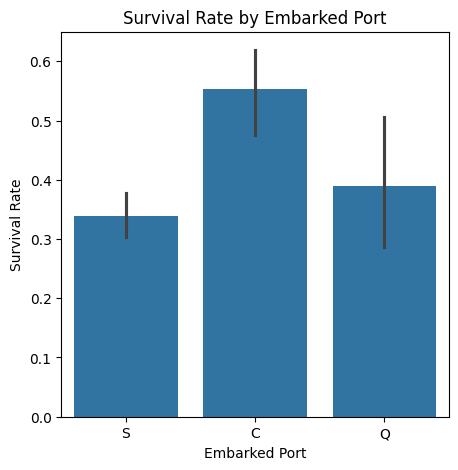

In [63]:
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='Embarked', y='Survived')
plt.title("Survival Rate by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Survival Rate")
plt.show()

**Q10. Does Observed Survival differ by deck?**

In [64]:
df.groupby("Deck")['Survived'].agg(['count','mean'])

,count,mean
Deck,,
A,15,0.466667
B,47,0.744681
C,59,0.593220
D,33,0.757576
E,32,0.750000
F,13,0.615385
G,4,0.500000
T,1,0.000000
Unknown,687,0.299854


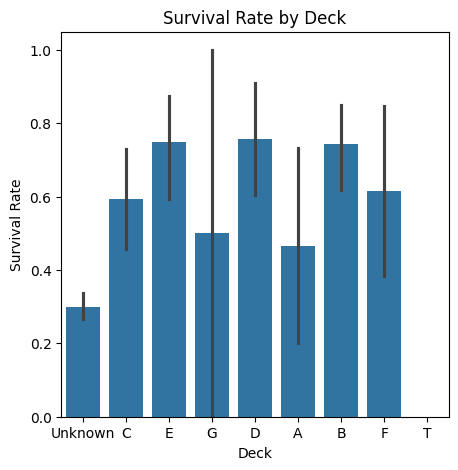

In [65]:
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='Deck', y='Survived')
plt.title("Survival Rate by Deck")
plt.ylabel("Survival Rate")
plt.show()

**Q11. Cabin recorded vs Survival?**

In [66]:
df.groupby('Cabin_known')['Survived'].agg(['count','mean'])

,count,mean
Cabin_known,,
0,687,0.299854
1,204,0.666667


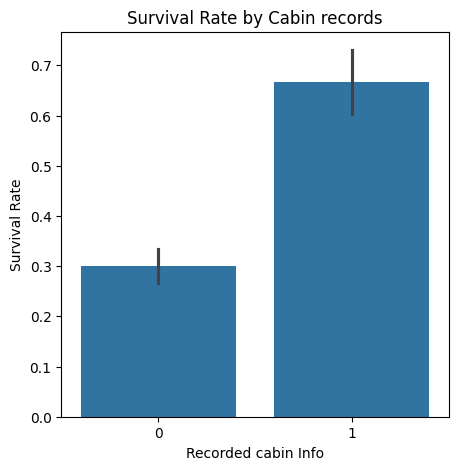

In [68]:
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='Cabin_known', y='Survived')
plt.title("Survival Rate by Cabin records")
plt.xlabel("Recorded cabin Info")
plt.ylabel("Survival Rate")
plt.show()

**Observation:**
- We can observe that no recorded should be treated as a feature, as we can only interpret with recorded data on their survival.

**Q12. Survival Rate by Passenger Class and Sex?**

In [69]:
survival_matrix = pd.pivot_table(
    df,
    values="Survived",
    index="Pclass",
    columns="Sex",
    aggfunc="mean"
)

survival_matrix

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


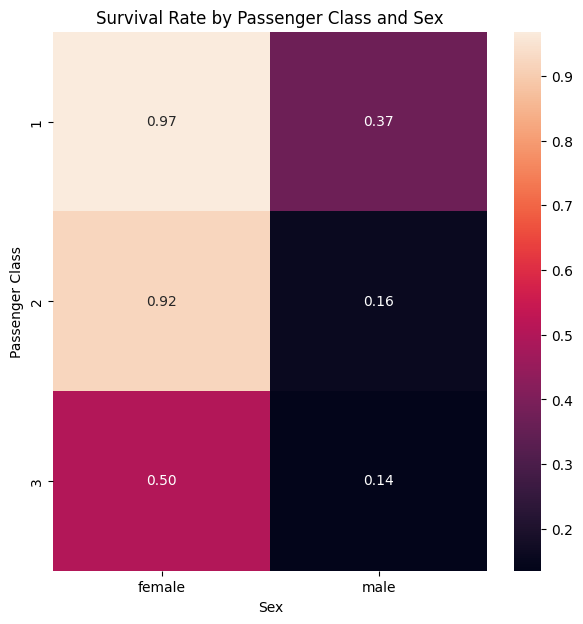

In [72]:
plt.figure(figsize=(7,7))
sns.heatmap(survival_matrix,annot=True,fmt=".2f")
plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Sex")
plt.ylabel("Passenger Class")
plt.show()

**6. Visualization**

**7. Insights / Findings**

**8. Recommendations**

**9. Conclusion**

**----------------------------------------------------------------END----------------------------------------------------------------------------**